In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as intg
from IPython.display import clear_output

from H2O2_formation import rate_const_H2O2

In [2]:
M_F=18.998E-3  #molar mass of fluoride in kg/mol
h_memb_117=183E-6

#the data in the loaded file was extracted from a diagram in the literature
FER_data=np.loadtxt("./Laconti_FER.txt") #[0:6] 1/T, [6:12] FER in µg/hr/cm², [12:14] x-values regression line, [14:16] y-values regression line

#the fluoride-emissions are given in µg/hr/cm² -> conversion to mol/l/s
FER_data[6:12]=FER_data[6:12]*10**4/(M_F*h_memb_117*3600*10**9*1000)
FER_data[14:16]=FER_data[14:16]*10**4/(M_F*h_memb_117*3600*10**9*1000)

In [3]:
#Nafion is C7HF13O5S.(C2F4)m with m being about 6, therefore 37 F per sulfonate acid group
EW=1.1  #equivalent weight of Nafion in kg/mol (weight of dry Nafion per mol of sulfonate acid groups)
M_F=18.998E-3  #molar mass of fluoride in kg/mol
m_F=37*M_F  #mass of fluoride = 0.703 kg per mol acid group
density_Nafion=1675  #density of water-swollen Nafion in kg/m³, from DOI: 10.1016/0376-7388(92)85007-6
density_F=density_Nafion*0.673  #m_F/EW  #m_F/EW is the relative contribution of fluoride to the whole weight, hence the density of
                                 #fluoride is the density of the polymer times this ratio; density given in kg/m³
c_F=density_F/(M_F*1000)  #fluoride concentration in Nafion in mol/l
print("Fluoride concentration: "+str(c_F)+" mol/l")

Fluoride concentration: 59.33650910622171 mol/l


In [4]:
#assignment of functions "rxn", "gas_trans" and "deg_rate"

#constants
m_H=2*1.66e-27  #mass of H2 in kg
m_O=32*1.66e-27  #mass of O2 in kg
m_H2O=18*1.66e-27  #mass of H2O in kg
M_H2O=18e-3  #molar mass of water in kg/mol
density_H2O=980  #density of water in kg/m³; changes with temperature, therefore this value as a compromise
EW=1.1  #equivalent weight of Nafion in kg/mol

kbT=1.38e-23  #Boltzmann constant in J/K
R=8.314  #gas constant in J/mol/K
N_A=6.022e23  #Avogadro constant in 1/mol
F=9.648e4  #Faraday constant in As/mol

T_0=1100  #the temperature in K at which the sticking coefficients were meassured
S_H2_0=0.05  #sticking coefficient for hydrogen at 1100 K
S_O2_0=0.02  #sticking coefficient for oxygen at 1100 K

h_decay=20e-9  #decay length of *OH in m, from 10.1149/1.3581040
V_decay=h_decay*1e-7

#this function takes T and curden and outputs values concerning H2 and O2
def gas_trans(T,curden,P_cat,P_an,h_memb):
    P_cat_H2=[P_cat]
    P_an_O2=[P_an]
#     i=0
#     while i<10:
#         #hydrogen and oxygen pressure at cathode and anode respectively
#         P_cat_H2.append(P_cat+24*(4.65e-14*P_cat_H2[i]+2e-14*(P_cat_H2[i]-P_an_O2[i]))*curden/(4.65e-14*P_cat_H2[i]))
#         P_an_O2.append(P_an+28*curden)
#         i+=1
    
    #formation rates
    f_H2=curden/(2*F)  #hydrogen formation rate in mol/m²*s
    f_O2=curden/(4*F)  #oxygen formation rate in mol/m²*s
    
    #water speed through the membrane
    v_H2O=(-0.332*np.log10(curden)+5.59)*M_H2O*curden/(2*F*density_H2O)  #velocity of water in m/s; depending on current density
    v_H2O=v_H2O*h_memb/(178e-6)
    
    #diffusion (dif_coeff from 10.1016/j.ijhydene.2011.05.127)
    dif_coeff_H2=2.51e-05*np.exp(-16.51e3/(R*T))  #diffusion coefficient in m²/s
    dif_coeff_O2=1.90e-05*np.exp(-18.38e3/(R*T))
    sol_H2=0.72e-6  #solubility in mol/m³*Pa
    sol_O2=0.8e-6
    s_O2=sol_O2*P_an/1000  #solubility of O2 in Nafion in mol/l
    flux_dif_H2=dif_coeff_H2*sol_H2*P_cat_H2[-1]/h_memb  #diffusion flux in mol/m²*s
    flux_dif_O2=dif_coeff_O2*sol_O2*P_an_O2[-1]/h_memb
    #flux_dif_H2=4.65e-14*P_cat_H2[-1]/h_memb
    #flux_dif_O2=2e-14*P_an_O2[-1]/h_memb
        
    #drag
    drag_coeff=0.0134*T+0.03  #dimensionless drag coefficient
    c_H2O=40e3  #water concentration in Nafion in mol/m³
    flux_drag_H2=-0.13*np.log10(curden)*drag_coeff*P_cat_H2[-1]*sol_H2/(F*c_H2O)  #drag flux in mol/m²*s
    flux_drag_O2=0.13*np.log10(curden)*drag_coeff*P_an_O2[-1]*sol_O2/(F*c_H2O)
        
    #differential pressure
    flux_dp_H2=2e-14*(P_cat_H2[-1]-P_an_O2[-1])/h_memb  #dp flux in mol/m²*s
    flux_dp_O2=2e-14*(P_an_O2[-1]-P_cat_H2[-1])/h_memb
            
    #total flux
    flux_H2=flux_dif_H2+flux_dp_H2+flux_drag_H2  #total hydrogen flux in mol/m²*s
    flux_O2=flux_dif_O2+flux_dp_O2+flux_drag_O2  #total oxygen flux in mol/m²*s
    if flux_H2>f_H2:
        flux_H2=f_H2  #more H2 permeating than being created not possible
    if flux_O2>f_O2:
        flux_O2=f_O2  #more O2 permeating than being created not possible
    if flux_O2<0:
        flux_O2=0
        
    #ratios
    H2_in_O2=100*flux_H2/(flux_H2+f_O2)
    O2_in_H2=100*flux_O2/(flux_O2+f_H2)
    alpha=f_H2/(flux_O2+f_H2)
    
    #calculation of H2 and O2 source terms and concentrations
    r_H2=f_H2/(h_cat*1000)  #H2 rate in mol/l/s 
    r_O2=flux_O2/(h_memb*1000)  #O2 rate in mol/l/s
    
    c_H2=sol_H2*P_cat/1000  #H2 concentration in mol/l; set to the solubility because of massive H2 abundance
    c_O2=flux_O2/(v_H2O*1000)  #O2 concentration in mol/l
    if c_O2>s_O2:
        c_O2=s_O2  #concentration can't exceed solubility
    if c_O2<0:
        c_O2=0
    
    return [alpha, r_H2, r_O2, v_H2O, c_H2, c_O2, f_H2, O2_in_H2]

#Defining the reaction network
def rxn(Z,t):
    #reaction rates
    r9  = ((k9*((Z[6]*1000)**2)*(Z[1]*1000))/h_cat)/1000  # 2 proton + O2_g -> H2O2_g
    
    #fenton reactions
    r10 = k10*Z[3]*Z[4]*Z[6]  # H2O2_g + Fe2 + proton -> OH* + H2O_g + Fe3
    r11 = k11*Z[8]*Z[4]*Z[6]  # OH* + Fe2 + proton -> H2O_g + Fe3
    r12 = k12*Z[7]*Z[4]*Z[6]  # HOO* + Fe2 + proton -> H2O2_g + Fe3
    r13 = k13*Z[7]*Z[5]       # HOO* + Fe3 -> O2_g + proton + Fe2
    r14 = k14*Z[3]*Z[5]       # H2O2_g + Fe3 -> HOO* + Fe2 + proton
    
    r15 = k15*Z[3]            # H2O2_g -> 2OH*
    r16 = k16*Z[3]*Z[8]       # H2O2_g + OH* -> HOO* + H2O_g
    r17 = k17*Z[3]*Z[7]       # H2O2_g + HOO* -> OH* + H2O_g + O2_g
    r18 = k18*Z[0]*Z[8]       # H2_g + OH* -> H* + H2O_g
    r19 = k19*Z[1]*Z[9]       # O2_g + H* -> HOO*
    r20 = k20*(Z[7]**2)       # 2HOO* -> H2O2_g + O2_g
    
    r21 = k21*Z[8]*c_COOH     # OH* + COOH -> products
    
    #convection terms only for long living species
    conv0 = Z[0]*v_H2O/h_memb  #H2
    conv1 = Z[1]*v_H2O/h_memb  #O2
    conv2 = Z[2]*v_H2O/h_memb  #H2O
    conv3 = Z[3]*v_H2O/h_memb  #H2O2
    conv4 = Z[4]*v_H2O/h_memb  #Fe2
    conv5 = Z[5]*v_H2O/h_memb  #Fe3
    
    #concentration change    
    dd0dt = 0# +r_H2-r18-conv0  #const.                # H2_g
    dd1dt = +r_O2+r13+r17+r20-r9-r19-conv1             # O2_g
    dd2dt = +r10+r11+r16+r17+r18-conv2                 # H2O_g
    dd3dt = +r9+r12+r20-r10-r14-r15-r16-r17-conv3      # H2O2_g
    dd4dt = +r_Fe2+r13+r14-r10-r11-r12-conv4           # Fe2
    dd5dt = +r_Fe3+r10+r11+r12-r13-r14-conv5           # Fe3
    dd6dt = 0# +r13+r14-2*r9-r10-r11-r12-r17  #const.  # proton
    dd7dt = +r14+r16+r19-r12-r13-2*r20                 # HOO*
    dd8dt = +r10+2*r15+r17-r11-r16-r18-r21             # OH*
    dd9dt = +r18-r19                                   # H*
    dd10dt= +r21                                       # attacks
           
    #    Z[H2_g,  O2_g,  H2O_g, H2O2_g, Fe2+,   Fe3+,   proton, HOO*,   OH*,    H*,    attacks]
    return[dd0dt, dd1dt, dd2dt, dd3dt, dd4dt, dd5dt, dd6dt, dd7dt, dd8dt, dd9dt, dd10dt]

def deg_rate(T,curden,P_cat,P_an,h_memb,f_Fe,pre_k9):
    #gas_trans outputs f(T,curden,P_cat,P_an,h_memb)
    global r_H2, r_O2, c_H2, c_O2, v_H2O, f_H2, r_Fe2, r_Fe3
    r_H2=gas_trans(T,curden,P_cat,P_an,h_memb)[1]  #source rate of H2 in mol/l/s
    r_O2=0.01*gas_trans(T,curden,P_cat,P_an,h_memb)[2]  #source rate of O2 in mol/l/s
    c_H2=gas_trans(T,curden,P_cat,P_an,h_memb)[4]  #H2 concentration in mol/l from Gubler
    c_O2=gas_trans(T,curden,P_cat,P_an,h_memb)[5]  #7.5E-3  #O2 concentration in mol/l from Gubler
    v_H2O=gas_trans(T,curden,P_cat,P_an,h_memb)[3]  #water speed in m/s
    f_H2=gas_trans(T,curden,P_cat,P_an,h_memb)[6]  #hydrogen formation rate in mol/m²/s
    r_Fe2=f_Fe*v_H2O  #source term for Fe2+ in mol/l/s
    r_Fe3=f_Fe*v_H2O  #source term for Fe3+ in mol/l/s
    
    #reaction constants f(T)
    global k9, k10, k11, k12, k13, k14, k15, k16, k17, k18, k19, k20, k21
    #(k10-k21 from Gubler et al 2011)
    #k10-k14 fenton reactions
    k10=1.03E8*np.exp(-35.4E3/(R*T))  # H2O2_g + Fe2 + proton -> OH* + H2O_g + Fe3
    k11=8.68E9*np.exp(-9E3/(R*T))     # OH* + Fe2 + proton -> H2O_g + Fe3
    k12=2.74E13*np.exp(-42E3/(R*T))   # HOO* + Fe2 + proton -> H2O2 + Fe3
    k13=1.21E10*np.exp(-33E3/(R*T))   # HOO* + Fe3 -> O2_g + proton + Fe2
    k14=8.31E18*np.exp(-126E3/(R*T))  # H2O2_g + Fe3 -> HOO* + Fe2 + proton
    k15=1.09E13*np.exp(-200E3/(R*T))  # H2O2_g -> 2OH*
    k16=7.66E9*np.exp(-14E3/(R*T))    # H2O2_g + OH* -> HOO* + H2O_g
    k17=5.41E5*np.exp(-30E3/(R*T))    # H2O2_g + HOO* -> OH* + H2O_g + O2_g
    k18=4.3E7                         # H2_g + OH* -> H* + H2O_g
    k19=1.2E10                        # O2_g + H* -> HOO*
    k20=3.5E9*np.exp(-20.6E3/(R*T))   # 2HOO* -> H2O2_g + O2
    k21=1.35E7*np.exp(-6.5E3/(R*T))   # OH* + COOH -> products

    #rate_const_H2O2()[0] always gives an array of k9 against current density, [abs(j-curden).argmin()] to pick out the desired current density
    j=np.linspace(0,30000,10000)  #current density over which k9 is calculated (see H2O2_formation notebook)
    j[0]=j[1]
    k9=pre_k9*rate_const_H2O2(T,P_cat,P_an,h_memb)[0][abs(j-curden).argmin()]  # 2 proton + O2_g -> H2O2
    
    t = np.linspace(0,3000,100)
    t_step = t[1]-t[0]
    Z0=[c_H2,c_O2,0,0,c_Fe2,c_Fe3,c_proton,0,0,0,0]
    conc=intg.odeint(rxn, Z0, t, rtol=4.0E-8, atol=1.0E-10)
    
    attack_rate=np.diff(conc[:,10])[-1]/t_step
    return [attack_rate]

In [5]:
#temperature dependance
#parameters
T=np.linspace(321,422,100)  #temperature in K
P_cat=6.7e5                 #cathode pressure in Pa
P_an=6.7e5                  #anode pressure in Pa
h_memb=183e-6               #membrane thickness in m
h_cat=10e-6                 #cathode thickness in m
h_an=10e-6                  #anode thickness in m

c_COOH=1.17                                  #concentration of COOH-endgroups in mol/l
c_Fe2=7.0E-8                                 #starting concentration of Fe2+ ions in mol/l
c_Fe3=7.0E-8                                 #starting concentration of Fe3+ ions in mol/l
c_proton=(1980+32.4*16)/(1+0.00648*16)/1000  #proton concentration in the ionomer in mol/l

#function execution
# 1. creating a list for each set of parameters
attack_rate1=[]
attack_rate2=[]
attack_rate3=[]
attack_rate4=[]
attack_rate5=[]
attack_rate6=[]
error_upper=[]
error_lower=[]
# 2. running the function deg_rate() with each set of parameters; the function only takes single values not lists or arrays, therefore this loop
i=0
while i<len(T):
    attack_rate1.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e1,1)[0])
    attack_rate2.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e0,1)[0])
    attack_rate3.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e-1,1)[0])
    attack_rate4.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e-2,1)[0])
    attack_rate5.append(deg_rate(T[i],1000,P_cat,P_an,h_memb,1e-2,1)[0])
    attack_rate6.append(deg_rate(T[i],20000,P_cat,P_an,h_memb,1e-2,1)[0])
    error_upper.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e0,2.46)[0])
    error_lower.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e0,0.34)[0])
    clear_output(wait=True)
    print(i)
    i+=1
# 3. converting the lists to np.arrays for better handling
attack_rate1=np.array(attack_rate1)
attack_rate2=np.array(attack_rate2)
attack_rate3=np.array(attack_rate3)
attack_rate4=np.array(attack_rate4)
attack_rate5=np.array(attack_rate5)
attack_rate6=np.array(attack_rate6)
error_upper=np.array(error_upper)
error_lower=np.array(error_lower)

99


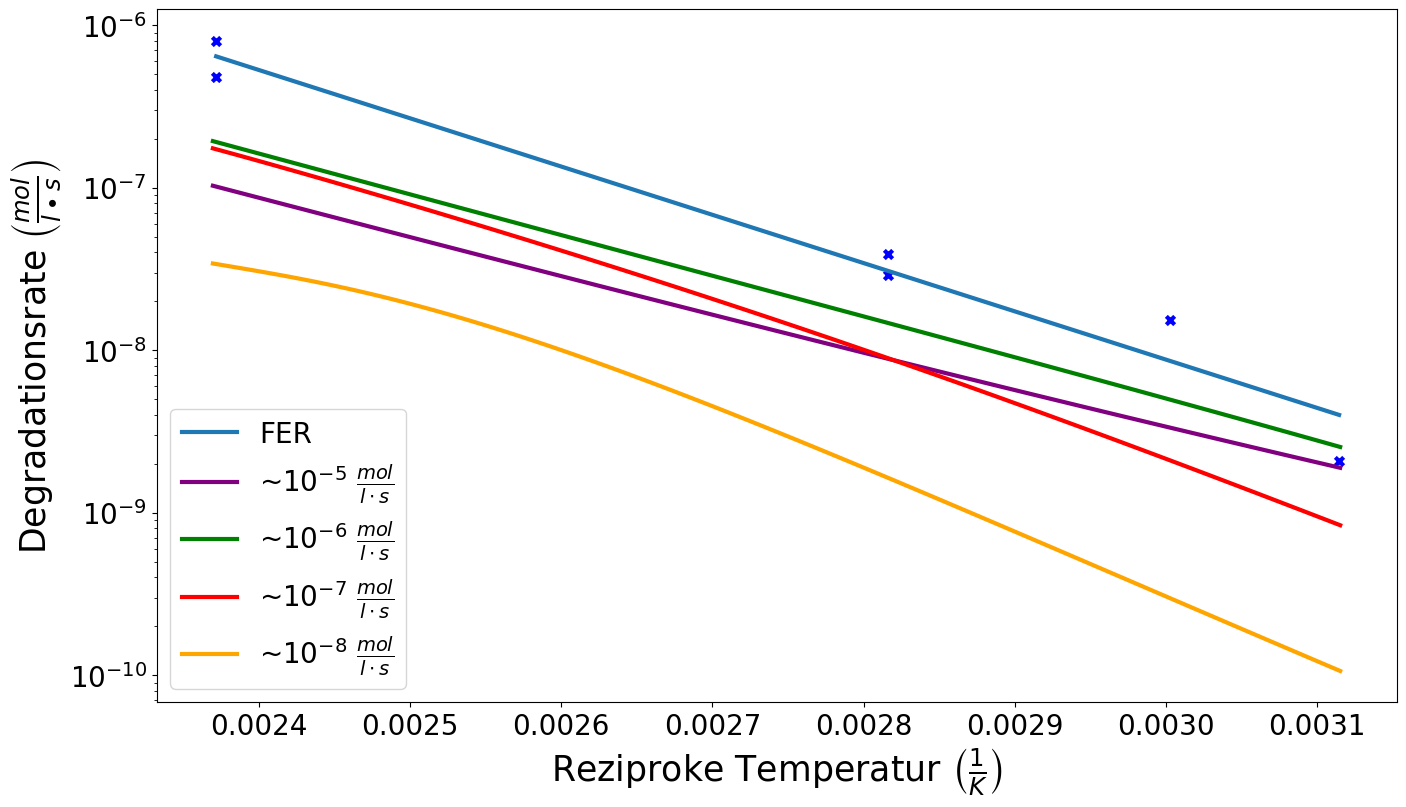

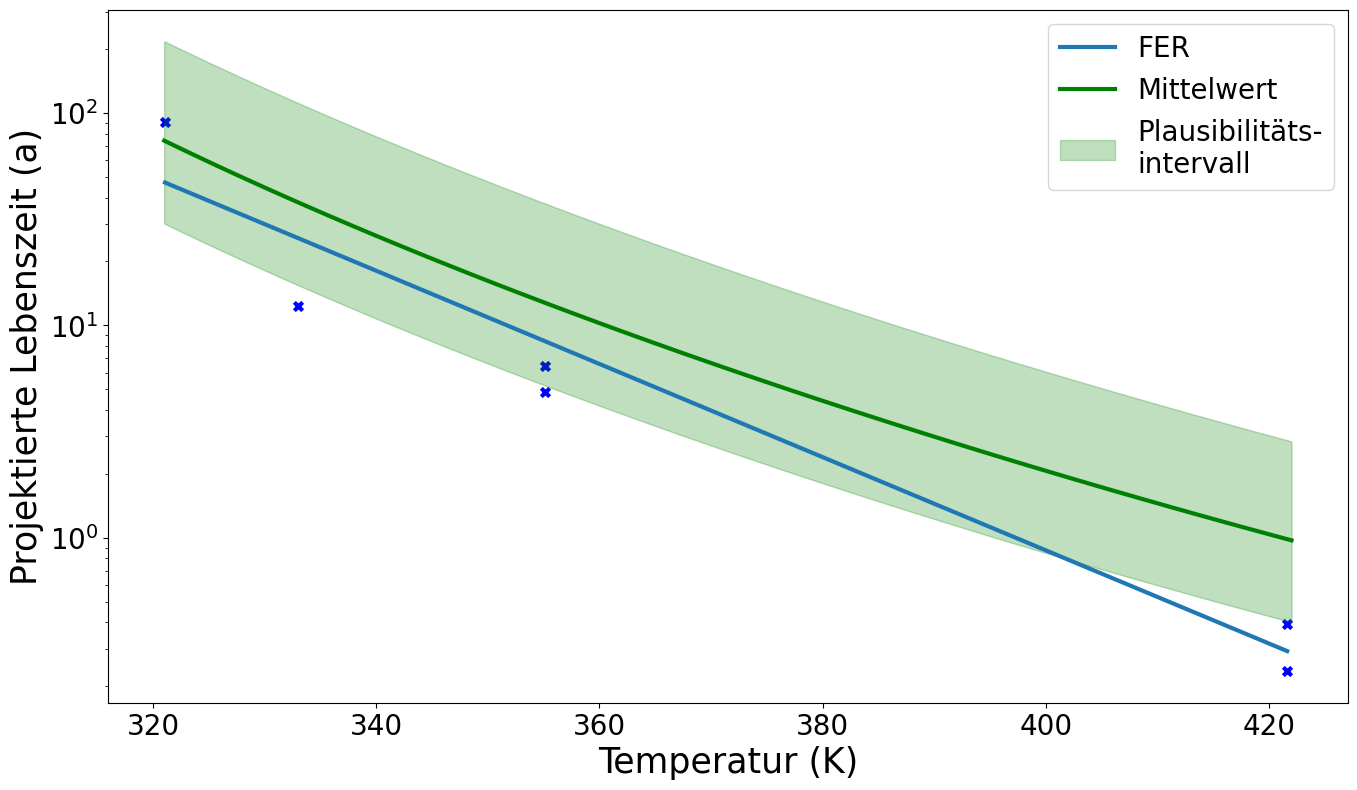

In [6]:
plt.figure(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
plt.scatter(FER_data[0:6], FER_data[6:12], color="blue", marker="x")
plt.plot(FER_data[12:14], FER_data[14:16], label="FER")
plt.plot(1/T, attack_rate1, color="purple", label=r"~10$^{-5}$ $\frac{mol}{l\cdot s}$")#, 1.08 $\frac{A}{cm^2}$")
plt.plot(1/T, attack_rate2, color="green", label=r"~10$^{-6}$ $\frac{mol}{l\cdot s}$")#, 1.08 $\frac{A}{cm^2}$")
plt.plot(1/T, attack_rate3, color="red", label=r"~10$^{-7}$ $\frac{mol}{l\cdot s}$")#, 1.08 $\frac{A}{cm^2}$")
plt.plot(1/T, attack_rate4, color="orange", label=r"~10$^{-8}$ $\frac{mol}{l\cdot s}$")#, 1.08 $\frac{A}{cm^2}$")
# plt.plot(1/T, attack_rate5, color="darkorange", linestyle="dashed", label=r"~10$^{-8}$ $\frac{mol}{l\cdot s}$, 0.10 $\frac{A}{cm^2}$")
# plt.plot(1/T, attack_rate6, color="darkorange", linestyle="dotted", label=r"~10$^{-8}$ $\frac{mol}{l\cdot s}$, 2.00 $\frac{A}{cm^2}$")
plt.xlabel(r"Reziproke Temperatur $\left(\frac{1}{K}\right)$", fontsize=25)
plt.ylabel(r"Degradationsrate $\left(\frac{mol}{l \bullet s}\right)$", fontsize=25)
plt.legend(loc="lower left", fontsize=20)
plt.yscale("log")
plt.show()

#lifetime calculations
lifetime_FER=c_F*0.1/(FER_data[6:12]*3600*365*24)  #lifetime of FER in years
lifetime_FER_line=c_F*0.1/(FER_data[14:16]*3600*365*24)
lifetime2=c_F*0.1/(attack_rate2*3600*365*24)  #lifetime of attack_rate2 in years
lifetime_upper=c_F*0.1/(error_upper*3600*365*24)  #lifetime of error_upper in years
lifetime_lower=c_F*0.1/(error_lower*3600*365*24)  #lifetime of error_lower in years

plt.figure(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
plt.scatter(1/FER_data[0:6], lifetime_FER, marker="x", color="blue")
plt.plot(1/FER_data[12:14], lifetime_FER_line,label="FER")
plt.plot(T, lifetime2, linewidth=3, color="green", label="Mittelwert")
# plt.plot(T, lifetime_upper, color="green", alpha=.5)
# plt.plot(T, lifetime_lower, color="green", alpha=.5)
plt.fill_between(T, lifetime_upper, lifetime_lower, color="green", alpha=.25, label="Plausibilitäts-\nintervall")
# plt.xlabel("temperature (K)", fontsize=25)
# plt.ylabel("projected lifetime (h)", fontsize=25)
plt.xlabel("Temperatur (K)", fontsize=25)
plt.ylabel("Projektierte Lebenszeit (a)", fontsize=25)
plt.yscale("log")
plt.legend()
plt.show()